# Model Metrics Visualization

Visualizes `metrics.csv`. Produces **8 figures** — one for each `(drop_address, drop_coord)` ablation
[`(0, 0)`, `(0, 1)`, `(1, 0)`, `(1, 1)`] **× each target** [`price`, `price_per_sqft`].

Each figure lays out the metrics (`RMSE`, `MAE`, `MAPE`, `R2`, `Adjusted_R2`) across columns. Within
every subplot the models are grouped on the x-axis with separate bars for the train and test split.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("metrics.csv")
df.head()

,timestamp,model,target,drop_address,drop_coord,split,metric,value
0,2026-06-04T22:49:09,dt,price,0,0,train,RMSE,133292.324353
1,2026-06-04T22:49:09,dt,price,0,0,train,MAE,87900.090985
2,2026-06-04T22:49:09,dt,price,0,0,train,MAPE,18.348209
3,2026-06-04T22:49:09,dt,price,0,0,train,R2,0.823491
4,2026-06-04T22:49:09,dt,price,0,0,train,Adjusted_R2,0.822487


In [2]:
# Fixed model order for the x-axis (mlp before mgbdt).
models = ["dt", "mlp", "mgbdt"]
targets = ["price", "price_per_sqft"]
metrics = ["RMSE", "MAE", "MAPE", "R2", "Adjusted_R2"]
splits = ["train", "test"]
combos = [(0, 0), (0, 1), (1, 0), (1, 1)]

split_colors = {"train": "#4C72B0", "test": "#DD8452"}
print("models:", models)

models: ['dt', 'mlp', 'mgbdt']


In [ ]:
def plot_combo(drop_address, drop_coord, target):
    """One figure of grouped bars for a single (drop_address, drop_coord, target) setting."""
    sub = df[
        (df["drop_address"] == drop_address)
        & (df["drop_coord"] == drop_coord)
        & (df["target"] == target)
    ]

    fig, axes = plt.subplots(
        1,
        len(metrics),
        figsize=(4 * len(metrics), 4),
        squeeze=False,
    )

    x = np.arange(len(models))
    width = 0.38

    for c, metric in enumerate(metrics):
        ax = axes[0][c]
        for i, split in enumerate(splits):
            vals = []
            for model in models:
                row = sub[
                    (sub["metric"] == metric)
                    & (sub["split"] == split)
                    & (sub["model"] == model)
                ]["value"]
                vals.append(row.iloc[0] if len(row) else np.nan)
            offset = (i - 0.5) * width
            bars = ax.bar(
                x + offset,
                vals,
                width,
                label=split,
                color=split_colors[split],
            )
            # ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

        ax.set_xticks(x)
        ax.set_xticklabels(models)
        ax.set_title(metric)
        ax.grid(axis="y", alpha=0.3)

    # Single shared legend for the whole figure.
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=len(splits))
    fig.suptitle(
        f"{target}  |  drop_address={drop_address}, drop_coord={drop_coord}",
        fontsize=14,
        fontweight="bold",
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    return fig

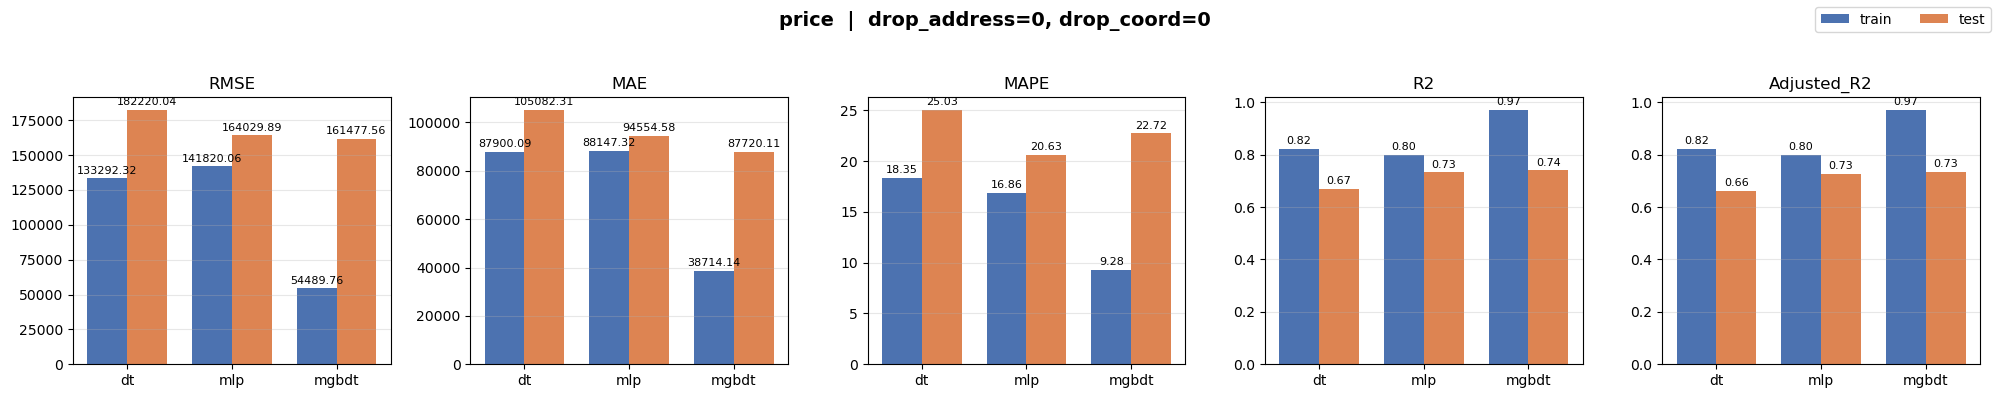

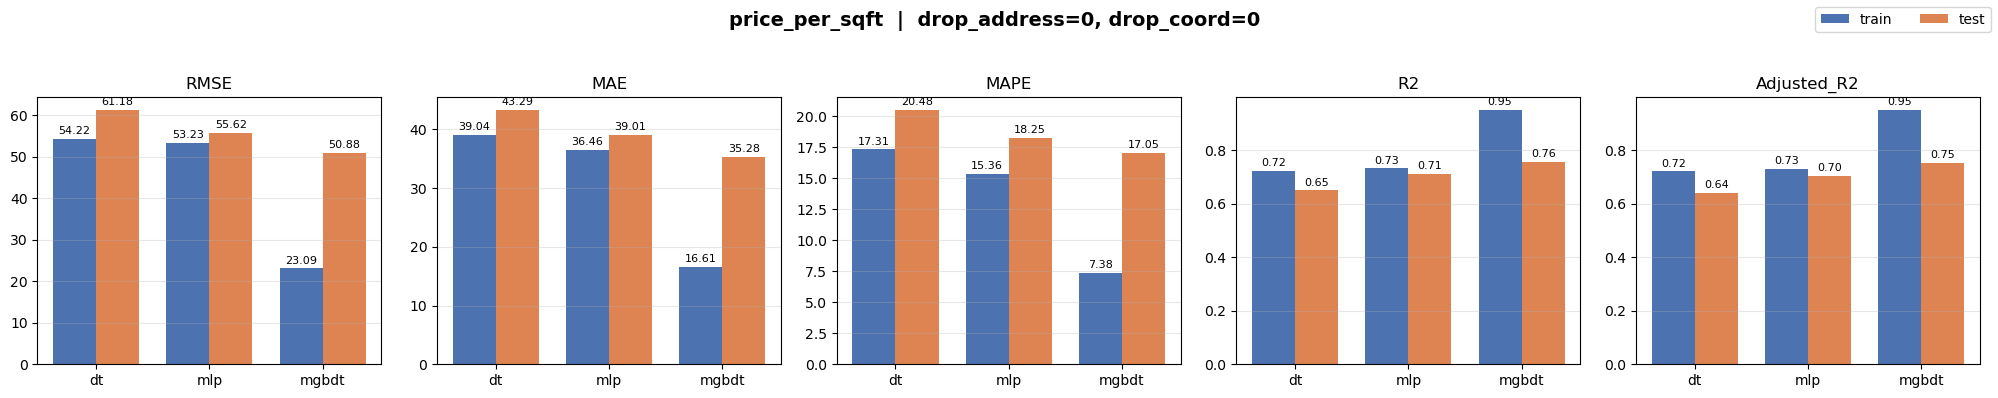

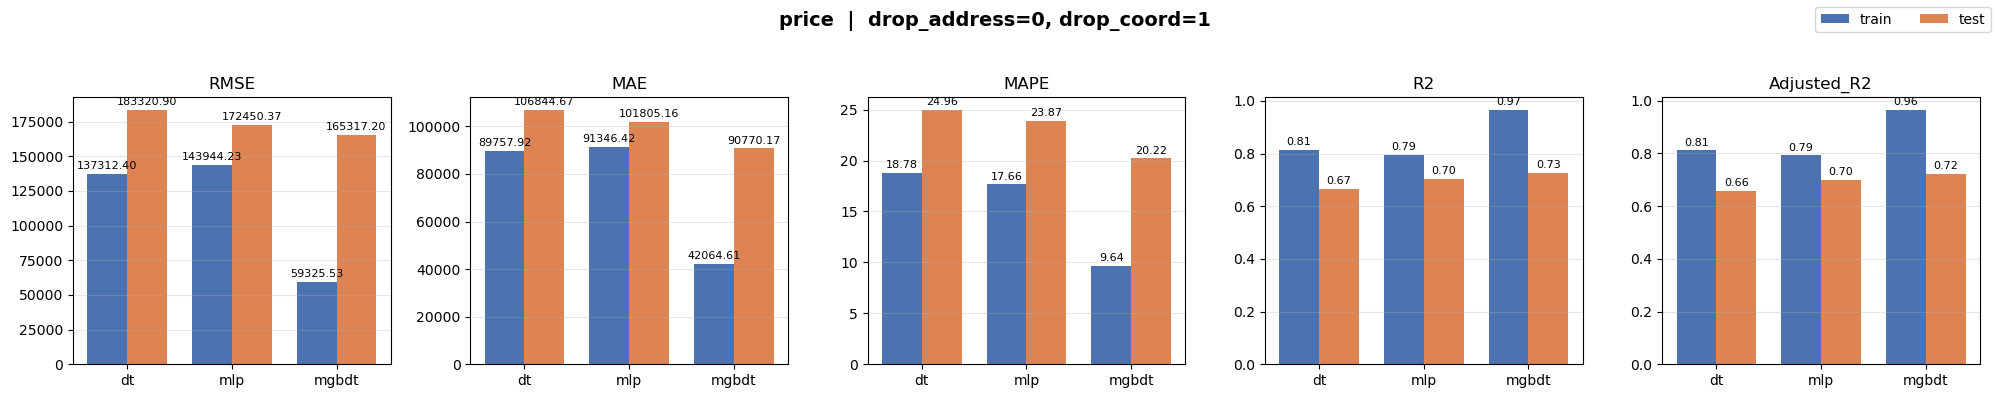

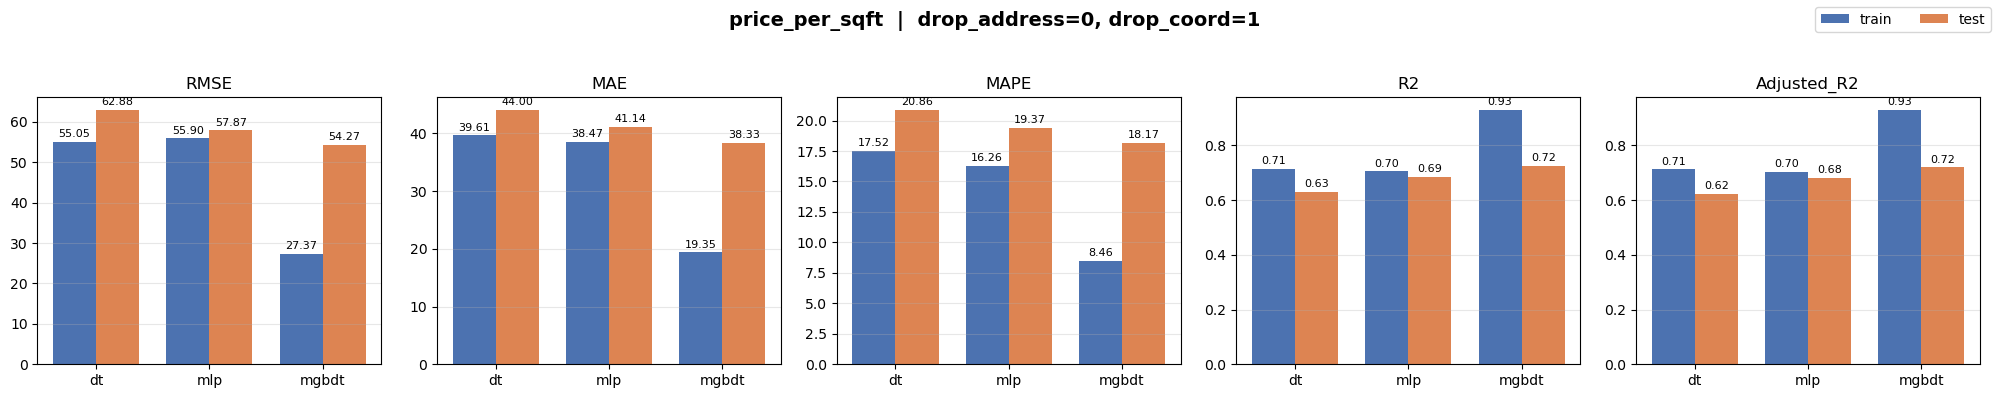

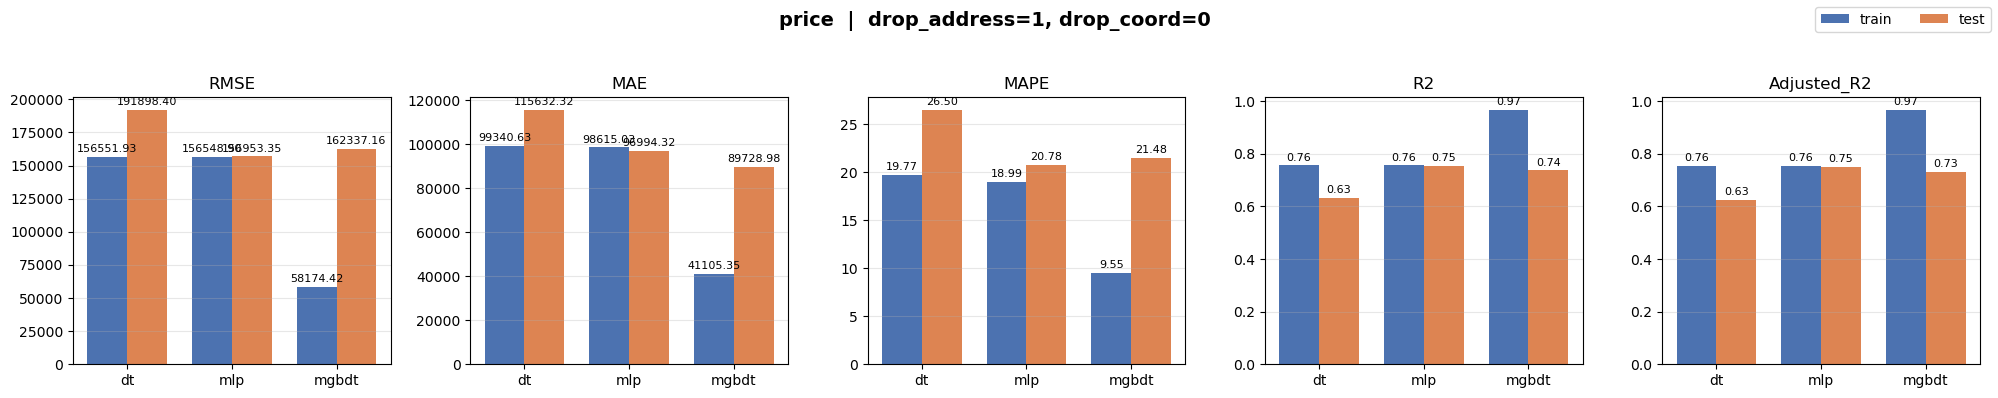

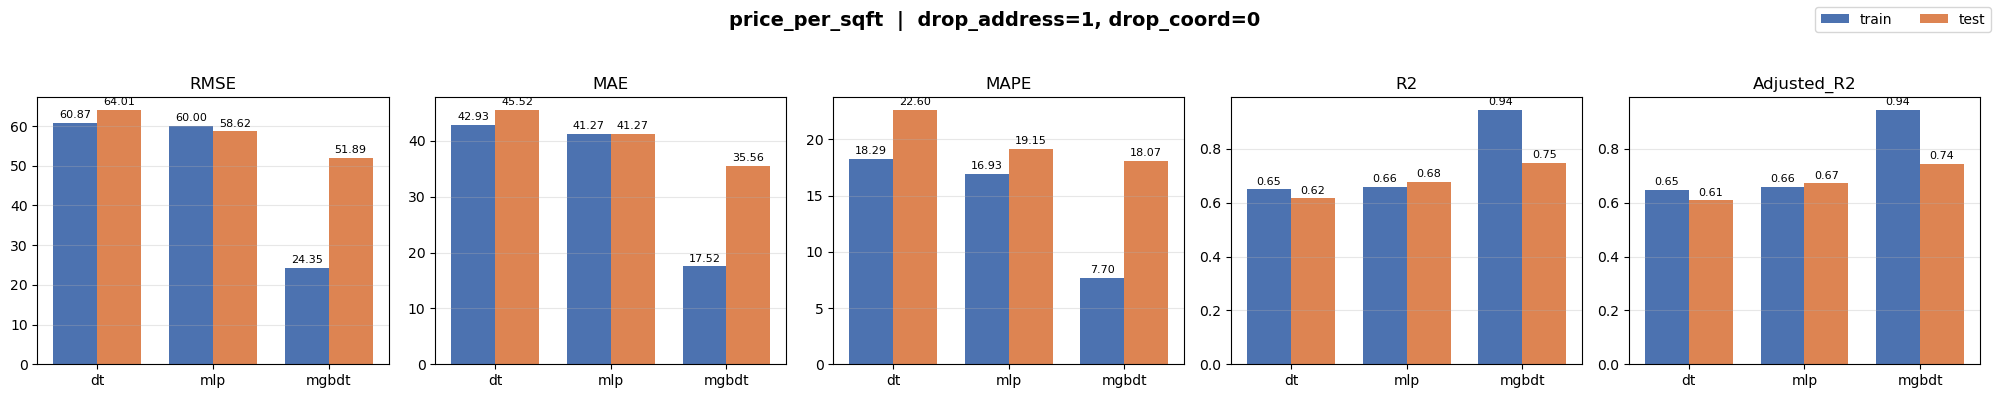

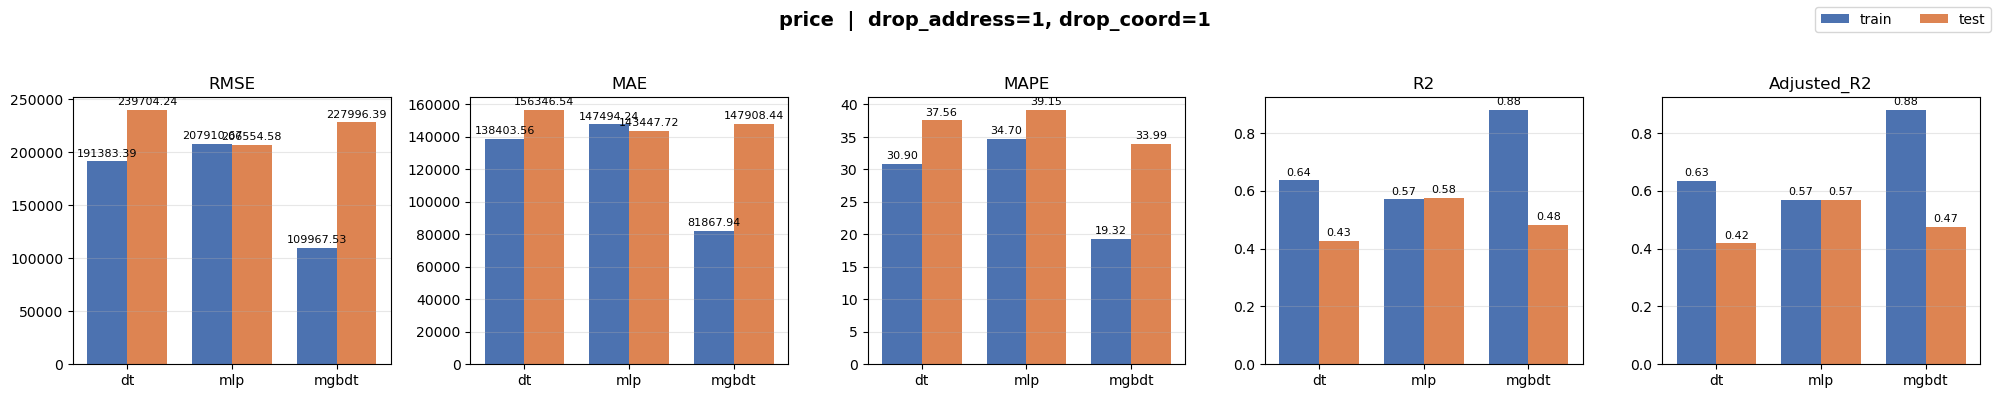

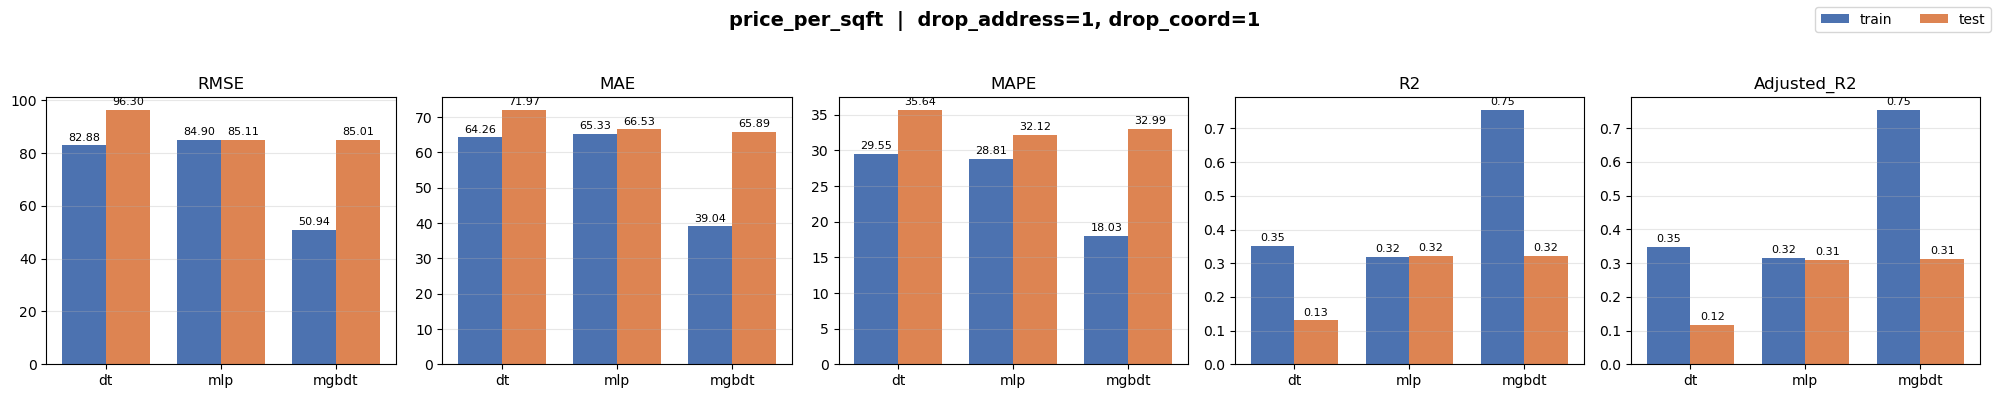

In [ ]:
for drop_address, drop_coord in combos:
    for target in targets:
        fig = plot_combo(drop_address, drop_coord, target)
        fig.savefig(
            f"metrics_{target}_da{drop_address}_dc{drop_coord}.png",
            dpi=120,
            bbox_inches="tight",
        )
        plt.show()